In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns
import os



from utils.participant_data import load_participant, load_all_participants
from utils.catchtrials import CatchTrials, add_conditions_by_sentence
from utils.gazedata import GazeData
from utils.pres_mapper import PresentationMapper 


In [8]:
REAL_ORDER_PATH = os.path.join("data", "sentences.js")

participants = load_all_participants()
conditions_df = pd.read_excel("data/sentences_newconditions.xlsx")

In [ ]:
REAL_ORDER_PATH = os.path.join("data", "sentences.js")

gaze_by_participant = {}
mapper_by_participant = {}
pupil_by_participant = {}

for i in participants.keys():
    p = participants[i]

    gaze_path = p.file_paths.get("gaze")
    if gaze_path is not None:
        try:
            gaze_by_participant[i] = GazeData(gaze_path)
        except KeyError as e:
            print(f"  FAILED on participant {i}, file {gaze_path}: {e}")
            continue
    else:
        print(f"  WARNING: no gaze file for participant {i}, skipping in gaze_by_participant")

    exp_order_path = p.file_paths.get("sentence_order")
    if exp_order_path is not None:
        mapper_by_participant[i] = PresentationMapper(
            real_order_path=REAL_ORDER_PATH,
            exp_order_path=exp_order_path,
        )
    else:
        print(f"  WARNING: no sentence_order file for participant {i}, skipping in mapper_by_participant")

    # ── Pupil data, remapped to real_index and tagged with conditions ──────
    if i in gaze_by_participant and i in mapper_by_participant:
        try:
            df_pupil = gaze_by_participant[i].pupil_timecourse_grid_all_presentations(n_points=101)

            mapper = mapper_by_participant[i]
            pres_to_real = mapper.get_pres_to_real_map()
            df_pupil["real_index"] = df_pupil["pres"].map(pres_to_real)

            unmapped = df_pupil["real_index"].isna().sum()
            if unmapped:
                print(f"  WARNING: participant {i} has {unmapped} pupil rows with no real_index mapping")

            df_pupil = df_pupil.drop(columns=["pres"])

            # Attach sentence text via the mapper's exp_order (real_index -> first),
            # so add_conditions_by_sentence can match it against conditions_df.
            sentence_lookup = mapper.exp_order[["real_index", "first"]].drop_duplicates(subset=["real_index"])
            df_pupil = df_pupil.merge(sentence_lookup, on="real_index", how="left")

            df_pupil = add_conditions_by_sentence(df_pupil, conditions_df, catch_col="first", cond_col="Part 1")
            df_pupil["participant_nr"] = i

            pupil_by_participant[i] = df_pupil
        except Exception as e:
            print(f"  WARNING: failed to process pupil data for participant {i}: {e}")
    else:
        print(f"  WARNING: missing gaze or mapper for participant {i}, skipping in pupil_by_participant")

pupil_all = pd.concat(pupil_by_participant.values(), ignore_index=True) if pupil_by_participant else pd.DataFrame()

print(pupil_all.shape)
print(pupil_all.columns.tolist())
print(f"gaze loaded for {len(gaze_by_participant)} participants, mapper for {len(mapper_by_participant)}, pupil for {len(pupil_by_participant)}")

KeyError: 'Expected a USER-like event column in gaze data, but none was found.'

In [ ]:
pupil_all.to_csv("data/pupil_data.csv")

In [ ]:
pupil_all.info

<bound method DataFrame.info of        time_pct  norm_pupil_raw  norm_pupil_pct  real_index  \
0           0.0       -0.531181       -3.954962           6   
1           1.0       -0.309560       -2.304861           6   
2           2.0       -0.252253       -1.878176           6   
3           3.0       -0.232995       -1.734790           6   
4           4.0       -0.158376       -1.179204           6   
...         ...             ...             ...         ...   
96955      96.0        1.905624       12.605943          26   
96956      97.0        1.876213       12.411385          26   
96957      98.0        2.187809       14.472633          26   
96958      99.0        1.985377       13.133518          26   
96959     100.0        1.947940       12.885869          26   

                                                   first Uncertainty  \
0      Sophie arrive au bureau avec un sourire énigma...        High   
1      Sophie arrive au bureau avec un sourire énigma...        Hig

In [ ]:
pupil_all[pupil_all["real_index"] == 7]["first"].unique

<bound method Series.unique of 8888     Une femme lui tendit de l'argent dans la rue.
8889     Une femme lui tendit de l'argent dans la rue.
8890     Une femme lui tendit de l'argent dans la rue.
8891     Une femme lui tendit de l'argent dans la rue.
8892     Une femme lui tendit de l'argent dans la rue.
                             ...                      
94632    Une femme lui tendit de l'argent dans la rue.
94633    Une femme lui tendit de l'argent dans la rue.
94634    Une femme lui tendit de l'argent dans la rue.
94635    Une femme lui tendit de l'argent dans la rue.
94636    Une femme lui tendit de l'argent dans la rue.
Name: first, Length: 1010, dtype: str>

# Plots - visualization

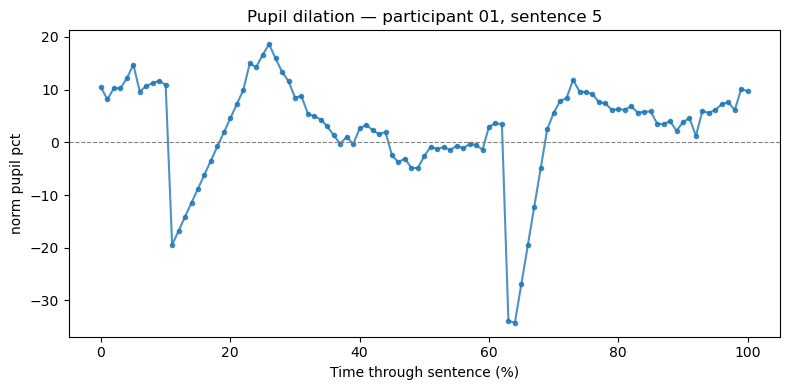

In [ ]:
def plot_pupil_by_real_index(pupil_all, participant_nr, real_index, value_col="norm_pupil_raw"):
    """Plot raw pupil dilation (or another pupil column) as a function of
    percent-time-through-sentence, for one participant and one real sentence index.

    pupil_all    : the concatenated pupil dataframe (participant_nr, real_index,
                   time_pct, norm_pupil_raw, norm_pupil_pct, ...)
    participant_nr : which participant to plot
    real_index   : which real sentence index to plot
    value_col    : which pupil column to plot on the y-axis
                   ("norm_pupil_raw" by default, or "norm_pupil_pct")
    """
    subset = pupil_all[
        (pupil_all["participant_nr"] == participant_nr) &
        (pupil_all["real_index"] == real_index)
    ].sort_values("time_pct")

    if subset.empty:
        print(f"No pupil data found for participant {participant_nr}, real_index {real_index}")
        return

    plt.figure(figsize=(8, 4))
    plt.plot(subset["time_pct"], subset[value_col], marker="o", markersize=3, alpha=0.8)
    plt.title(f"Pupil dilation — participant {participant_nr}, sentence {real_index}")
    plt.xlabel("Time through sentence (%)")
    plt.ylabel(value_col.replace("_", " "))
    plt.axhline(0, color="grey", linewidth=0.8, linestyle="--")
    plt.tight_layout()
    plt.show()

plot_pupil_by_real_index(pupil_all, "01", 5, "norm_pupil_pct")

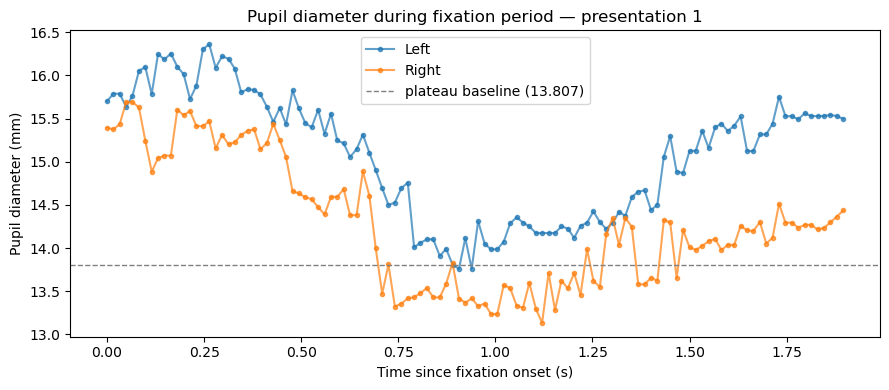

In [ ]:
gd = gaze_by_participant["01"]
gd.plot_pupil_during_fixation(pres=1)

In [ ]:
def plot_pupil_timecourse_by_condition(
    df_pupil: pd.DataFrame,
    value_col: str = "norm_pupil_pct",
    ci: str = "se",  # "se" or "ci95"
):
    """Line plot: one subplot per Uncertainty x Resolution, 4 lines per subplot
    (Unc Valence x Res Valence), each line = mean value_col across participants
    at each time_pct, with a shaded band for participant variability.

    This preserves the time axis instead of collapsing it — use this to see
    WHEN conditions diverge, not just whether their averages differ.
    """
    cond_cols = ["Uncertainty", "Resolution", "Unc Valence", "Res Valence"]
    group_cols = ["participant_nr", "time_pct"] + cond_cols
    df = df_pupil.dropna(subset=[value_col] + group_cols)

    # one value per (participant, time_pct, condition) -- averaged across sentences
    per_participant_time = (
        df.groupby(group_cols)[value_col].mean().reset_index()
    )

    stats = (
        per_participant_time.groupby(["time_pct"] + cond_cols)[value_col]
        .agg(mean="mean", std="std", n="count")
        .reset_index()
    )
    stats["se"] = stats["std"] / np.sqrt(stats["n"])
    stats["band"] = stats["se"] * (1.96 if ci == "ci95" else 1.0)

    combos = (
        stats[["Uncertainty", "Resolution"]]
        .drop_duplicates().sort_values(["Uncertainty", "Resolution"])
        .itertuples(index=False, name=None)
    )
    combos = list(combos)
    n = len(combos)
    ncols = min(2, n) if n > 1 else 1
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 4.5 * nrows), squeeze=False, sharey=True)
    axes_flat = axes.flatten()

    line_specs = [
        ("Pos", "Pos", "Unc+ / Res+", "mediumseagreen"),
        ("Pos", "Neg", "Unc+ / Res−", "seagreen"),
        ("Neg", "Pos", "Unc− / Res+", "salmon"),
        ("Neg", "Neg", "Unc− / Res−", "firebrick"),
    ]

    for ax_idx, (unc, res) in enumerate(combos):
        ax = axes_flat[ax_idx]
        sub = stats[(stats["Uncertainty"] == unc) & (stats["Resolution"] == res)]
        for uv, rv, label, color in line_specs:
            line = sub[(sub["Unc Valence"] == uv) & (sub["Res Valence"] == rv)].sort_values("time_pct")
            if line.empty:
                continue
            ax.plot(line["time_pct"], line["mean"], label=label, color=color)
            ax.fill_between(line["time_pct"], line["mean"] - line["band"], line["mean"] + line["band"],
                             color=color, alpha=0.15)
        ax.axhline(0, color="grey", linewidth=0.5, linestyle="--")
        ax.set_title(f"Uncertainty: {unc} | Resolution: {res}")
        ax.set_xlabel("time_pct")
        ax.set_ylabel(value_col)
        ax.legend(fontsize=8)

    for j in range(len(combos), len(axes_flat)):
        axes_flat[j].axis("off")

    fig.suptitle(f"{value_col} time course by condition", fontsize=13)
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    return fig

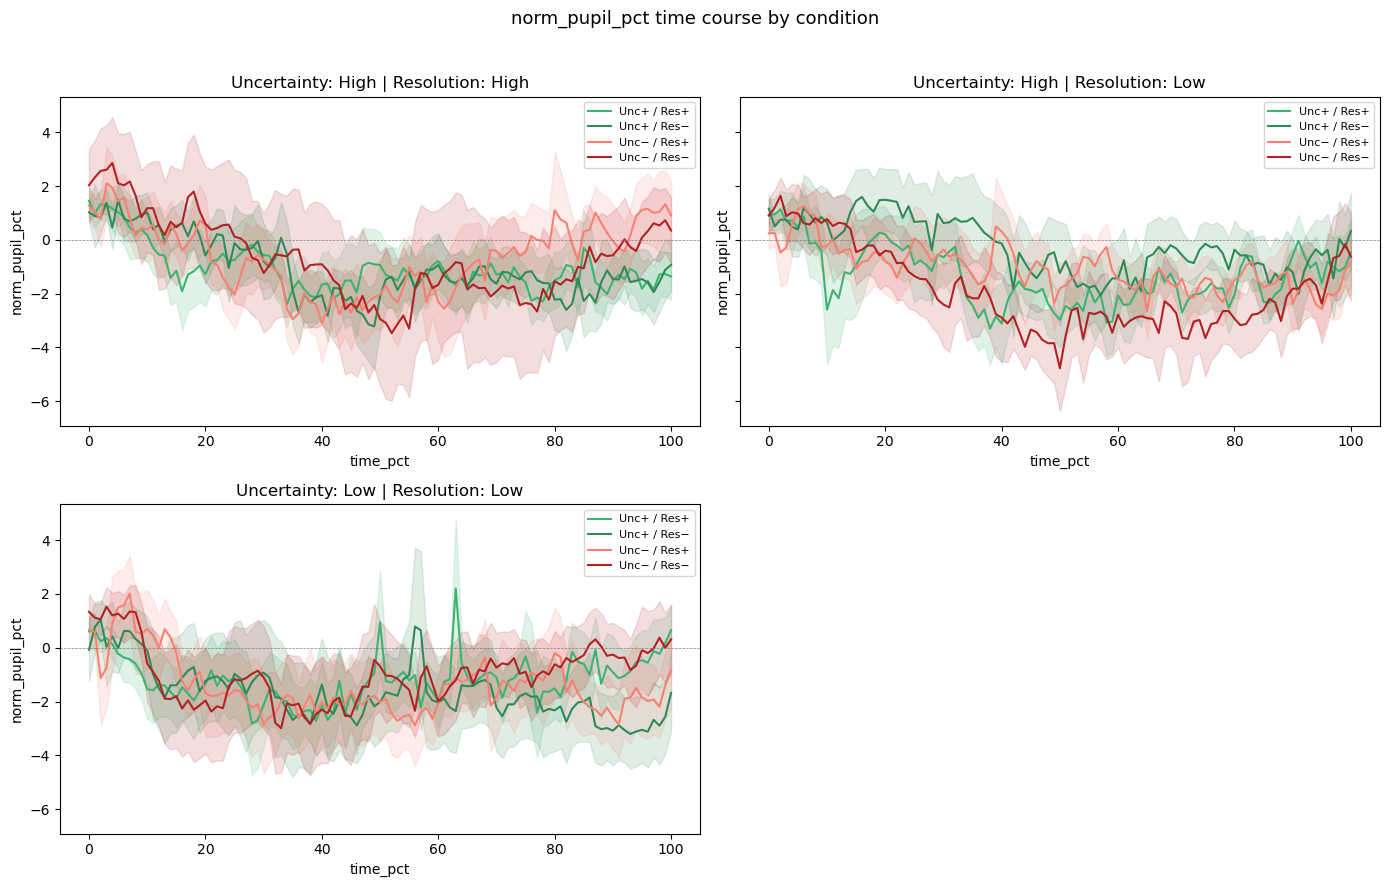

In [ ]:
fig = plot_pupil_timecourse_by_condition(pupil_all)
plt.show()